# 02 — Self-report vs treatment vs measured value

For each condition with both a questionnaire item and an objectively measured biomarker, this notebook reports:

- **Prevalence** of self-report, of treatment, and of an elevated biomarker (each as a weighted proportion of the adult population).
- **Awareness/treatment/control cascade**: of those with elevated biomarker (or treated for the condition), what fraction self-report a diagnosis, what fraction of those are on treatment, what fraction of those are controlled.
- **Agreement plot** where the comparison is point-against-point (self-report BMI vs measured BMI; self-report smoking vs cotinine).

**Cohort:** Adults ≥20, pooled NHANES 2013-2018 cycles (`sr_comparison_2013_2018.parquet`). Liver stiffness uses the 2017–March 2020 pre-pandemic release (only NHANES source for LSM).

**Cut-points (definition of "elevated"):**

| Condition | Biomarker | Cut-point | Reference |
| --- | --- | --- | --- |
| Hypertension | SBP (mean of 3) | ≥ 140 mmHg | JNC 7 / NHANES standard |
| High cholesterol | Total cholesterol | ≥ 240 mg/dL | ATP III "high TC" |
| Diabetes | Fasting glucose | ≥ 126 mg/dL | ADA |
| Kidney dysfunction | eGFR (CKD-EPI 2021) | < 60 mL/min/1.73m² | KDIGO G3a+ |
| Significant liver fibrosis | LSM (VCTE) | ≥ 8 kPa | EASL clinical practice guideline |
| Current smoking | Serum cotinine | ≥ 10 ng/mL | NHANES active-smoker threshold |

**Variance:** weighted proportions; SEs by paired-PSU jackknife on `SDMVPSU × SDMVSTRA`; 95 % CIs from `±1.96 × SE`.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path

DATA = Path(os.path.abspath(os.path.join('..', 'data')))
DERIVED = DATA / 'derived'
OUT = Path('outputs'); OUT.mkdir(exist_ok=True)

comp = pd.read_parquet(DERIVED / 'sr_comparison_2013_2018.parquet')
lsm = pd.read_parquet(DERIVED / 'sr_lsm_p2017_2020.parquet')
print(f'comparison cohort (2013-2018): {len(comp):,} adults ≥20')
print(f'LSM cohort (P_2017-2020):     {len(lsm):,} adults ≥20')

comparison cohort (2013-2018): 16,327 adults ≥20
LSM cohort (P_2017-2020):     8,544 adults ≥20


## Weighted-proportion helper with paired-PSU jackknife

Standard NHANES variance approach: for each (`SDMVSTRA`, `SDMVPSU`) cell, set one PSU's weight to 0 and double the other's, recompute the proportion, accumulate squared deviations.

In [2]:
def w_prop(values, weights):
    m = ~np.isnan(values) & (weights > 0)
    if m.sum() == 0:
        return np.nan
    return float(np.average(values[m], weights=weights[m]))

def paired_jk_prop(df, var, wt='weight', psu='SDMVPSU', stratum='SDMVSTRA',
                   filter_mask=None):
    sub = df[[var, wt, psu, stratum]].copy()
    if filter_mask is not None:
        sub = sub[filter_mask.loc[sub.index]]
    sub = sub.dropna(subset=[var, wt, psu, stratum])
    sub = sub[sub[wt] > 0]
    if len(sub) < 30:
        return np.nan, np.nan, len(sub)
    v = sub[var].values.astype(float)
    w = sub[wt].values.astype(float)
    s = sub[stratum].astype(int).values
    p = sub[psu].astype(int).values
    theta = w_prop(v, w)
    var_sum = 0.0
    for st in np.unique(s):
        in_st = (s == st)
        psus = np.unique(p[in_st])
        if len(psus) < 2:
            continue
        for pu in psus:
            wr = w.copy()
            mask_in = in_st & (p == pu)
            mask_other = in_st & (p != pu)
            wr[mask_in] = 0.0
            wr[mask_other] = wr[mask_other] * 2.0
            theta_r = w_prop(v, wr)
            if not np.isnan(theta_r):
                var_sum += (theta_r - theta) ** 2
    return theta, np.sqrt(var_sum), len(sub)


def prop_row(label, df, var, wt='weight', filter_mask=None):
    theta, se, n = paired_jk_prop(df, var, wt=wt, filter_mask=filter_mask)
    return {
        'group': label, 'n': n,
        'pct': 100 * theta if theta is not None else np.nan,
        'lo': 100 * (theta - 1.96 * se) if theta is not None else np.nan,
        'hi': 100 * (theta + 1.96 * se) if theta is not None else np.nan,
    }

## 1. Hypertension — SBP ≥ 140 vs BPQ020 vs BPQ050A

In [3]:
df = comp.copy()
df['SBP_HIGH'] = (df['SBP_MEAN'] >= 140).astype(float)
df.loc[df['SBP_MEAN'].isna(), 'SBP_HIGH'] = np.nan
df['HBP_ANY'] = ((df['SBP_HIGH'] == 1) | (df['HBP_TRT'] == 1)).astype(float)
df.loc[df['SBP_HIGH'].isna() & df['HBP_TRT'].isna(), 'HBP_ANY'] = np.nan

# Skip-pattern fix: BPQ050A is null for people who answered "no" to BPQ020.
# In the cascade denominator (all hypertensive), they are untreated → impute 0.
df['HBP_TRT_IMP'] = df['HBP_TRT'].fillna(0).where(~df['HBP_SELF'].isna(), np.nan)

rows = []
rows.append(prop_row('all: SBP ≥ 140 (measured)',  df, 'SBP_HIGH'))
rows.append(prop_row('all: ever told HBP (self-report)',   df, 'HBP_SELF'))
rows.append(prop_row('all: on antihypertensive med',       df, 'HBP_TRT_IMP'))
rows.append(prop_row('all: hypertensive (either)',         df, 'HBP_ANY'))
# Cascade — denominator = anyone meeting "hypertensive" definition
hyp = df[df['HBP_ANY'] == 1].copy()
rows.append(prop_row('hyp: % aware (self-report)',         hyp, 'HBP_SELF'))
rows.append(prop_row('hyp: % treated (on med)',            hyp, 'HBP_TRT_IMP'))
# Controlled = SBP<140 among treated
trt = df[df['HBP_TRT_IMP'] == 1].copy()
trt['CTRL'] = (trt['SBP_MEAN'] < 140).astype(float)
trt.loc[trt['SBP_MEAN'].isna(), 'CTRL'] = np.nan
rows.append(prop_row('hyp+trt: % controlled (SBP<140)',    trt, 'CTRL'))
hbp_table = pd.DataFrame(rows).round(1)
print(hbp_table.to_string(index=False))

                           group     n  pct   lo   hi
       all: SBP ≥ 140 (measured) 15706 15.2 13.8 16.5
all: ever told HBP (self-report) 16308 33.3 31.2 35.4
    all: on antihypertensive med 16308 24.1 22.3 25.8
      all: hypertensive (either) 15905 32.4 30.4 34.3
      hyp: % aware (self-report)  6015 84.2 81.8 86.5
         hyp: % treated (on med)  6015 76.2 73.4 79.0
 hyp+trt: % controlled (SBP<140)  4440 69.5 66.9 72.1


## 2. High cholesterol — TC ≥ 240 vs BPQ080 vs BPQ100D

In [4]:
df = comp.copy()
df['TC_HIGH'] = (df['LBXTC'] >= 240).astype(float)
df.loc[df['LBXTC'].isna(), 'TC_HIGH'] = np.nan
df['HC_ANY'] = ((df['TC_HIGH'] == 1) | (df['HC_TRT'] == 1)).astype(float)
df.loc[df['TC_HIGH'].isna() & df['HC_TRT'].isna(), 'HC_ANY'] = np.nan

df['HC_TRT_IMP'] = df['HC_TRT'].fillna(0).where(~df['HC_SELF'].isna(), np.nan)

rows = []
rows.append(prop_row('all: TC ≥ 240 (measured)',   df, 'TC_HIGH'))
rows.append(prop_row('all: ever told high cholesterol',     df, 'HC_SELF'))
rows.append(prop_row('all: on cholesterol med',             df, 'HC_TRT_IMP'))
rows.append(prop_row('all: high cholesterol (either)',      df, 'HC_ANY'))
hc = df[df['HC_ANY'] == 1].copy()
rows.append(prop_row('hc: % aware',                         hc, 'HC_SELF'))
rows.append(prop_row('hc: % treated',                       hc, 'HC_TRT_IMP'))
trt = df[df['HC_TRT_IMP'] == 1].copy()
trt['CTRL'] = (trt['LBXTC'] < 240).astype(float)
trt.loc[trt['LBXTC'].isna(), 'CTRL'] = np.nan
rows.append(prop_row('hc+trt: % controlled (TC<240)',       trt, 'CTRL'))
hc_table = pd.DataFrame(rows).round(1)
print(hc_table.to_string(index=False))

                          group     n  pct   lo   hi
       all: TC ≥ 240 (measured) 15436 11.4 10.2 12.6
all: ever told high cholesterol 16215 33.9 32.0 35.7
        all: on cholesterol med 16215 18.2 16.8 19.7
 all: high cholesterol (either) 15638 28.8 27.4 30.3
                    hc: % aware  4724 74.8 72.1 77.5
                  hc: % treated  4724 65.5 61.7 69.4
  hc+trt: % controlled (TC<240)  3121 92.6 90.7 94.6


## 3. Diabetes — FPG ≥ 126 vs DIQ010 vs DIQ050/070

Fasting glucose uses the fasting subsample weight (`WTSAF2YR / 3`).

In [5]:
df = comp.copy()
df['FPG_HIGH'] = (df['LBXGLU'] >= 126).astype(float)
df.loc[df['LBXGLU'].isna(), 'FPG_HIGH'] = np.nan
df['DM_ANY'] = ((df['FPG_HIGH'] == 1) | (df['DM_SELF'] == 1)).astype(float)
df.loc[df['FPG_HIGH'].isna() & df['DM_SELF'].isna(), 'DM_ANY'] = np.nan

rows = []
rows.append(prop_row('all: FPG ≥ 126 (measured)',           df, 'FPG_HIGH', wt='weight_fasting'))
rows.append(prop_row('all: ever told diabetes',             df, 'DM_SELF'))
rows.append(prop_row('all: on insulin or oral hypoglycemic',df, 'DM_TRT'))
rows.append(prop_row('all: diabetes (either)',              df, 'DM_ANY',   wt='weight_fasting'))
dm = df[df['DM_ANY'] == 1].copy()
rows.append(prop_row('dm: % aware',                         dm, 'DM_SELF',  wt='weight_fasting'))
rows.append(prop_row('dm: % treated',                       dm, 'DM_TRT',   wt='weight_fasting'))
trt = df[df['DM_TRT'] == 1].copy()
trt['CTRL'] = (trt['LBXGLU'] < 126).astype(float)
trt.loc[trt['LBXGLU'].isna(), 'CTRL'] = np.nan
rows.append(prop_row('dm+trt: % controlled (FPG<126)',      trt, 'CTRL',    wt='weight_fasting'))
dm_table = pd.DataFrame(rows).round(1)
print(dm_table.to_string(index=False))

                               group     n  pct   lo   hi
           all: FPG ≥ 126 (measured)  6955 11.4  9.9 12.9
             all: ever told diabetes 15860 11.2 10.2 12.2
all: on insulin or oral hypoglycemic 15860  9.7  8.8 10.5
              all: diabetes (either)  6955 14.6 12.9 16.3
                         dm: % aware  1300 77.5 72.9 82.2
                       dm: % treated  1300 68.8 63.3 74.3
      dm+trt: % controlled (FPG<126)   921 28.4 22.8 34.1


## 4. BMI — self-reported vs measured

No "treatment" column to cascade through; instead we validate the self-report. WHQ asks height (inches) and weight (pounds); we convert to kg/m² and compare to the BMX-measured BMXBMI.

n with both measured and self-reported BMI: 15,551
  weighted mean self-report − measured = -0.83 kg/m² (bias)
  weighted RMSE of self-report = 2.05 kg/m²
  weighted Pearson r = 0.965

Weighted % in each self-report BMI category, by measured BMI category:
cat_self  <18.5  18.5-25  25-30  30-35   35+
cat_meas                                    
<18.5      71.3     28.7    0.0    0.0   0.0
18.5-25     2.2     92.7    4.9    0.1   0.1
25-30       0.0     16.0   80.8    3.1   0.1
30-35       0.0      0.9   27.9   69.1   2.1
35+         0.0      0.1    1.1   22.3  76.5


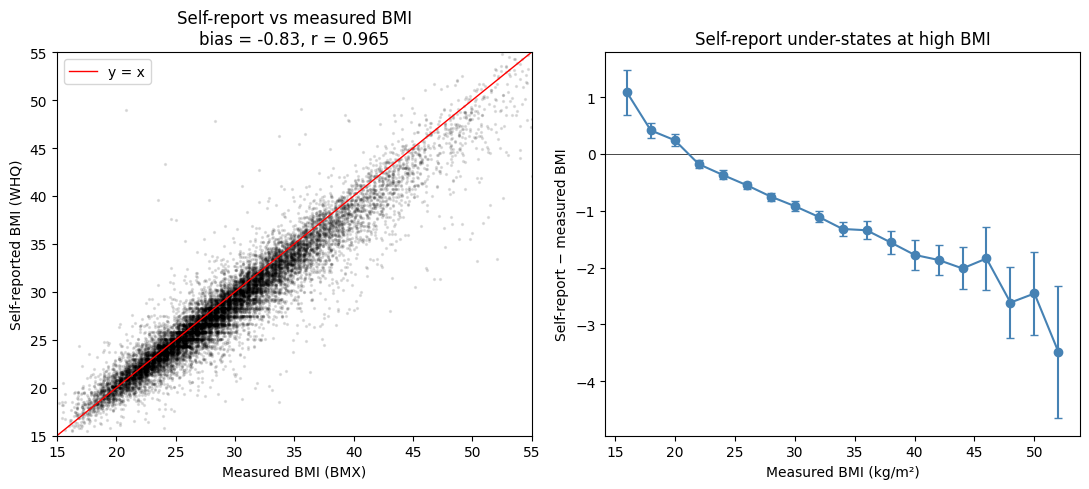

In [6]:
df = comp.dropna(subset=['BMXBMI', 'BMI_SELF', 'weight']).copy()
df = df[df['weight'] > 0]
print(f'n with both measured and self-reported BMI: {len(df):,}')

bias = np.average(df['BMI_SELF'] - df['BMXBMI'], weights=df['weight'])
rmse = np.sqrt(np.average((df['BMI_SELF'] - df['BMXBMI'])**2, weights=df['weight']))
mx = np.average(df['BMXBMI'], weights=df['weight'])
my = np.average(df['BMI_SELF'], weights=df['weight'])
cov = np.average((df['BMXBMI']-mx)*(df['BMI_SELF']-my), weights=df['weight'])
sx = np.sqrt(np.average((df['BMXBMI']-mx)**2, weights=df['weight']))
sy = np.sqrt(np.average((df['BMI_SELF']-my)**2, weights=df['weight']))
r = cov / (sx*sy)
print(f'  weighted mean self-report − measured = {bias:+.2f} kg/m² (bias)')
print(f'  weighted RMSE of self-report = {rmse:.2f} kg/m²')
print(f'  weighted Pearson r = {r:.3f}')

# WHO BMI categories
cats = [0, 18.5, 25, 30, 35, 100]
labels = ['<18.5', '18.5-25', '25-30', '30-35', '35+']
df['cat_meas'] = pd.cut(df['BMXBMI'], cats, labels=labels, right=False)
df['cat_self'] = pd.cut(df['BMI_SELF'], cats, labels=labels, right=False)
# weighted agreement
tab = (df.groupby(['cat_meas', 'cat_self'], observed=True)['weight'].sum()
         .unstack('cat_self', fill_value=0))
tab = tab.div(tab.sum(axis=1), axis=0) * 100
print('\nWeighted % in each self-report BMI category, by measured BMI category:')
print(tab.round(1).to_string())

# Plot: scatter + identity line
fig, ax = plt.subplots(1, 2, figsize=(11, 5))
ax[0].scatter(df['BMXBMI'], df['BMI_SELF'], s=2, alpha=0.10, color='k')
lo, hi = 15, 55
ax[0].plot([lo, hi], [lo, hi], 'r-', lw=1, label='y = x')
ax[0].set_xlim(lo, hi); ax[0].set_ylim(lo, hi)
ax[0].set_xlabel('Measured BMI (BMX)')
ax[0].set_ylabel('Self-reported BMI (WHQ)')
ax[0].set_title(f'Self-report vs measured BMI\nbias = {bias:+.2f}, r = {r:.3f}')
ax[0].legend()

# Bias by measured BMI
df['BMI_BIN'] = pd.cut(df['BMXBMI'], np.arange(15, 55, 2))
bias_by_bin = df.groupby('BMI_BIN', observed=True).apply(
    lambda g: np.average(g['BMI_SELF']-g['BMXBMI'], weights=g['weight']))
n_by_bin = df.groupby('BMI_BIN', observed=True)['weight'].count()
mid = [iv.mid for iv in bias_by_bin.index]
# CI via stratified SE
def bin_se(g):
    d = g['BMI_SELF'] - g['BMXBMI']
    if len(d) < 5: return np.nan
    return d.std() / np.sqrt(len(d))
se_by_bin = df.groupby('BMI_BIN', observed=True).apply(bin_se)
ax[1].errorbar(mid, bias_by_bin.values,
               yerr=1.96 * se_by_bin.values, fmt='o-', capsize=3, color='steelblue')
ax[1].axhline(0, color='k', lw=0.5)
ax[1].set_xlabel('Measured BMI (kg/m²)')
ax[1].set_ylabel('Self-report − measured BMI')
ax[1].set_title('Self-report under-states at high BMI')
plt.tight_layout(); plt.show()

## 5. Kidney dysfunction — eGFR < 60 vs KIQ022 vs KIQ025

In [7]:
df = comp.copy()
df['CKD'] = (df['eGFR'] < 60).astype(float)
df.loc[df['eGFR'].isna(), 'CKD'] = np.nan

rows = []
rows.append(prop_row('all: eGFR < 60 (CKD G3a+)',           df, 'CKD'))
rows.append(prop_row('all: weak/failing kidneys (KIQ022)',  df, 'KID_SELF'))
rows.append(prop_row('all: dialysis past 12 mo (KIQ025)',   df, 'DIALYSIS'))
ckd = df[df['CKD'] == 1].copy()
rows.append(prop_row('ckd: % self-report weak kidneys',     ckd, 'KID_SELF'))
rows.append(prop_row('ckd: % on dialysis',                  ckd, 'DIALYSIS'))
kid_table = pd.DataFrame(rows).round(2)
print(kid_table.to_string(index=False))

                             group     n   pct    lo    hi
         all: eGFR < 60 (CKD G3a+) 15392  5.94  5.29  6.60
all: weak/failing kidneys (KIQ022) 16305  3.01  2.53  3.48
 all: dialysis past 12 mo (KIQ025)   619  7.97  4.06 11.89
   ckd: % self-report weak kidneys  1241 22.81 18.46 27.15
                ckd: % on dialysis   313 14.62  6.51 22.73


## 6. Liver fibrosis — LSM ≥ 8 kPa vs MCQ160L

Uses the P_2017-2020 pre-pandemic release. "Aware" denominator is the population with measured LSM ≥ 8 kPa and a valid FibroScan (IQR/median ≤ 0.30).

In [8]:
df = lsm.copy()
df = df[df['LSM_VALID'] == True]
df['LSM_HIGH'] = (df['LUXSMED'] >= 8).astype(float)
df.loc[df['LUXSMED'].isna(), 'LSM_HIGH'] = np.nan

rows = []
rows.append(prop_row('all: LSM ≥ 8 kPa (measured)',         df, 'LSM_HIGH'))
rows.append(prop_row('all: ever told liver condition',      df, 'LIVER_SELF'))
fib = df[df['LSM_HIGH'] == 1].copy()
rows.append(prop_row('lsm≥8: % self-report liver condition',fib, 'LIVER_SELF'))
liver_table = pd.DataFrame(rows).round(1)
print(liver_table.to_string(index=False))

                               group    n  pct  lo   hi
         all: LSM ≥ 8 kPa (measured) 7707  9.5 7.7 11.4
      all: ever told liver condition 7692  4.6 3.4  5.8
lsm≥8: % self-report liver condition  811 11.8 6.9 16.7


## 7. Smoking — cotinine vs SMQ020+SMQ040

In [9]:
df = comp.dropna(subset=['LBXCOT', 'SMOKE_CAT']).copy()
df['COT_SMOKER'] = (df['LBXCOT'] >= 10).astype(float)
df['SR_CURRENT'] = (df['SMOKE_CAT'] == 'current').astype(float)

# weighted crosstab
tab = (df.groupby(['SMOKE_CAT', 'COT_SMOKER'])['weight'].sum()
         .unstack(fill_value=0))
tab.columns = ['cot<10', 'cot≥10']
tab_pct = (tab.div(tab.sum(axis=1), axis=0) * 100).round(1)
print('Weighted % within each self-reported smoking category:')
print(tab_pct.to_string())

# Misclassification: cotinine≥10 among self-reported never/former
mis = df[df['SMOKE_CAT'].isin(['never', 'former'])].copy()
print(f'\nDeceivers (self-report never/former but cot ≥ 10 ng/mL):')
print(prop_row('  among never+former', mis, 'COT_SMOKER'))
mis2 = df[df['SMOKE_CAT'] == 'never'].copy()
print(prop_row('  among never only',    mis2, 'COT_SMOKER'))
# Sensitivity: of cotinine smokers, % self-report current
cot_smokers = df[df['COT_SMOKER'] == 1].copy()
print(prop_row('among cot≥10: % self-report current', cot_smokers, 'SR_CURRENT'))

Weighted % within each self-reported smoking category:
           cot<10  cot≥10
SMOKE_CAT                
current       7.1    92.9
former       83.8    16.2
never        95.2     4.8

Deceivers (self-report never/former but cot ≥ 10 ng/mL):
{'group': '  among never+former', 'n': 8260, 'pct': 8.290692204680907, 'lo': np.float64(7.143735062396453), 'hi': np.float64(9.43764934696536)}
{'group': '  among never only', 'n': 5853, 'pct': 4.791491063140683, 'lo': np.float64(3.553550604710362), 'hi': np.float64(6.029431521571003)}
{'group': 'among cot≥10: % self-report current', 'n': 2376, 'pct': 70.92259240232683, 'lo': np.float64(67.6497433041731), 'hi': np.float64(74.19544150048057)}


## Summary — awareness cascade across conditions

Awareness cascade across conditions (% of those with elevated biomarker):
       condition  aware_pct  aware_lo  aware_hi  treated_pct  ctrl_pct
    Hypertension       84.2      81.8      86.5         76.2      69.5
High cholesterol       74.8      72.1      77.5         65.5      92.6
        Diabetes       77.5      72.9      82.2         68.8      28.4
Kidney (eGFR<60)       22.8      18.5      27.2          NaN       NaN
   Liver (LSM≥8)       11.8       6.9      16.7          NaN       NaN


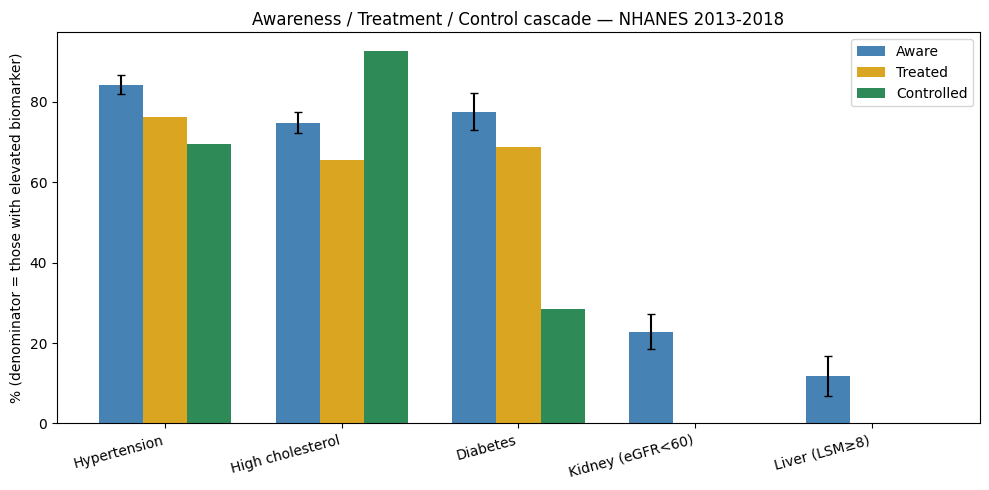

In [10]:
def cascade_summary(name, table, aware_row, treat_row=None, ctrl_row=None):
    aware = table.loc[table['group'].str.startswith(aware_row), ['pct', 'lo', 'hi']].iloc[0]
    out = {'condition': name, 'aware_pct': aware['pct'],
           'aware_lo': aware['lo'], 'aware_hi': aware['hi']}
    if treat_row:
        t = table.loc[table['group'].str.startswith(treat_row), ['pct']].iloc[0]
        out['treated_pct'] = t['pct']
    if ctrl_row:
        c = table.loc[table['group'].str.startswith(ctrl_row), ['pct']].iloc[0]
        out['ctrl_pct'] = c['pct']
    return out

summary = pd.DataFrame([
    cascade_summary('Hypertension', hbp_table, 'hyp: % aware', 'hyp: % treated', 'hyp+trt: % controlled'),
    cascade_summary('High cholesterol', hc_table, 'hc: % aware', 'hc: % treated', 'hc+trt: % controlled'),
    cascade_summary('Diabetes', dm_table, 'dm: % aware', 'dm: % treated', 'dm+trt: % controlled'),
    cascade_summary('Kidney (eGFR<60)', kid_table, 'ckd: % self-report'),
    cascade_summary('Liver (LSM≥8)', liver_table, 'lsm≥8: % self-report'),
]).round(1)
print('Awareness cascade across conditions (% of those with elevated biomarker):')
print(summary.to_string(index=False))

# Cascade bar plot
fig, ax = plt.subplots(figsize=(10, 5))
conds = summary['condition']
x = np.arange(len(conds))
w = 0.25
ax.bar(x - w, summary['aware_pct'], w,
       yerr=[summary['aware_pct'] - summary['aware_lo'],
             summary['aware_hi'] - summary['aware_pct']],
       capsize=3, label='Aware', color='steelblue')
ax.bar(x, summary['treated_pct'].fillna(0), w, label='Treated', color='goldenrod')
ax.bar(x + w, summary['ctrl_pct'].fillna(0), w, label='Controlled', color='seagreen')
ax.set_xticks(x); ax.set_xticklabels(conds, rotation=15, ha='right')
ax.set_ylabel('% (denominator = those with elevated biomarker)')
ax.set_title('Awareness / Treatment / Control cascade — NHANES 2013-2018')
ax.legend()
plt.tight_layout(); plt.show()